In [91]:
# 0. Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_completeness_v_measure,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

print("0. Импорт библиотек выполнен.")

0. Импорт библиотек выполнен.


In [92]:
# 1. Загрузка данных
print("\n1. Загрузка данных...")

url = "https://raw.githubusercontent.com/Uzzika/machine_learning_2025/main/hotel_bookings.csv"
df = pd.read_csv(url)


1. Загрузка данных...


In [93]:
# 2. Базовый анализ данных и целевой переменной

target_col = "is_canceled"

print("\n2. Базовый анализ данных...")

print("\nРаспределение целевой переменной is_canceled:")
print(df[target_col].value_counts())
print("\nДоли классов:")
print(df[target_col].value_counts(normalize=True))


2. Базовый анализ данных...

Распределение целевой переменной is_canceled:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Доли классов:
is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64


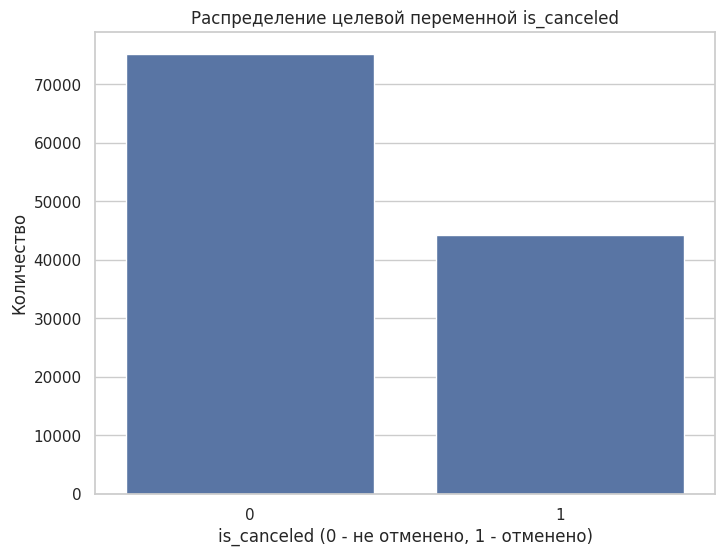

In [94]:
plt.figure()
sns.countplot(x=target_col, data=df)
plt.title("Распределение целевой переменной is_canceled")
plt.xlabel("is_canceled (0 - не отменено, 1 - отменено)")
plt.ylabel("Количество")
plt.show()

In [95]:
print("\nТоп-10 признаков по количеству пропусков:")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing.head(10))


Топ-10 признаков по количеству пропусков:


,0
company,112593
agent,16340
country,488
children,4
arrival_date_month,0
arrival_date_week_number,0
hotel,0
is_canceled,0
stays_in_weekend_nights,0
arrival_date_day_of_month,0


In [96]:
# 3. Подготовка данных

print("\n3. Подготовка данных...")

leaking_features = ["reservation_status", "reservation_status_date"]

existing_leaks = [col for col in leaking_features if col in df.columns]
print(f"Удаляем потенциально 'утекающие' признаки: {existing_leaks}")

df_clean = df.drop(columns=existing_leaks)
y = df_clean[target_col].values
X = df_clean.drop(columns=[target_col])

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")

# Разделим признаки по типам
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("\nКатегориальные признаки:")
print(cat_cols)
print("\nЧисловые признаки:")
print(num_cols)


3. Подготовка данных...
Удаляем потенциально 'утекающие' признаки: ['reservation_status', 'reservation_status_date']
Размер X: (119390, 29)
Размер y: (119390,)

Категориальные признаки:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Числовые признаки:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


In [97]:
# 4. Препроцессинг

print("\n4. Препроцессинг данных...")

X_prep = X.copy()

print("   - Заполняем пропуски...")

for col in num_cols:
    median_val = X_prep[col].median()
    X_prep[col] = X_prep[col].fillna(median_val)

for col in cat_cols:
    X_prep[col] = X_prep[col].fillna("Unknown")

print("   Пропуски заполнены.")

print("   - Кодируем категориальные признаки (One-Hot-Encoding)...")
X_dummies = pd.get_dummies(X_prep, columns=cat_cols, drop_first=True)
print(f"   Размер после OHE: {X_dummies.shape}")

print("   - Стандартизируем признаки...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_dummies)
print(f"   Размер X_scaled: {X_scaled.shape}")


4. Препроцессинг данных...
   - Заполняем пропуски...
   Пропуски заполнены.
   - Кодируем категориальные признаки (One-Hot-Encoding)...
   Размер после OHE: (119390, 248)
   - Стандартизируем признаки...
   Размер X_scaled: (119390, 248)


In [98]:
# 5. PCA: 2 компоненты для визуализации + 10 для DBSCAN

print("\n5. PCA: понижение размерности...")

# PCA до 2 компонент (для графиков)
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

explained_2 = pca2.explained_variance_ratio_.sum()
print(f"   Доля объяснённой дисперсии 2 компонентами: {explained_2:.4f}")

# PCA до 10 компонент (для DBSCAN)
pca10 = PCA(n_components=10, random_state=42)
X_pca10 = pca10.fit_transform(X_scaled)
explained_10 = pca10.explained_variance_ratio_.sum()
print(f"   Доля объяснённой дисперсии 10 компонентами: {explained_10:.4f}")


5. PCA: понижение размерности...
   Доля объяснённой дисперсии 2 компонентами: 0.0305
   Доля объяснённой дисперсии 10 компонентами: 0.1019


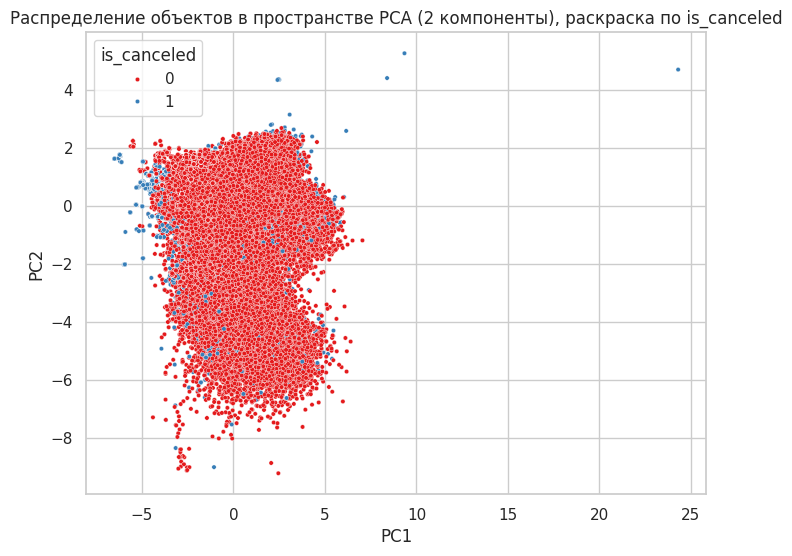

In [99]:
# Визуализация PCA2 по истинным меткам
plt.figure()
sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], hue=y, s=10, palette="Set1")
plt.title("Распределение объектов в пространстве PCA (2 компоненты), раскраска по is_canceled")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="is_canceled", loc="best")
plt.show()

In [100]:
# 6. Подвыборка для кластеризации

print("\n6. Подвыборка данных для кластеризации...")

np.random.seed(42)
n_samples = 5000
indices = np.random.choice(X_scaled.shape[0], size=n_samples, replace=False)

X_sub = X_scaled[indices]
X_pca2_sub = X_pca2[indices]
X_pca10_sub = pca10.transform(X_scaled)[indices]  # PCA10 только для подвыборки
y_sub = y[indices]

print(f"   Размер подвыборки X_sub: {X_sub.shape}")
unique_labels, counts = np.unique(y_sub, return_counts=True)
print("   Распределение классов is_canceled в подвыборке:")
for lab, cnt in zip(unique_labels, counts):
    print(f"   Класс {lab}: {cnt} объектов")


6. Подвыборка данных для кластеризации...
   Размер подвыборки X_sub: (5000, 248)
   Распределение классов is_canceled в подвыборке:
   Класс 0: 3097 объектов
   Класс 1: 1903 объектов


In [101]:
# 7. Функции оценки кластеризации

def evaluate_clustering(labels, y_true, name="model"):
    """
    Печатает метрики качества кластеризации и возвращает словарь.
    labels - предсказанные метки кластеров
    y_true - истинные метки (is_canceled)
    """
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    h, c, v = homogeneity_completeness_v_measure(y_true, labels)

    print(f"\n=== {name} ===")
    print(f"Adjusted Rand Index (ARI): {ari:.4f}")
    print(f"Normalized Mutual Information (NMI): {nmi:.4f}")
    print(f"Homogeneity: {h:.4f}")
    print(f"Completeness: {c:.4f}")
    print(f"V-measure: {v:.4f}")

    # кластеры vs истинные метки
    print("\nТаблица соответствия кластеров и истинных меток (crosstab):")
    ct = pd.crosstab(labels, y_true, rownames=["cluster"], colnames=["is_canceled"])
    display(ct)

    return {"ARI": ari, "NMI": nmi, "H": h, "C": c, "V": v, "crosstab": ct}

def map_clusters_to_classes(labels, y_true):
    """
    Для наглядности формируем приближённое отображение:
    каждому кластеру сопоставляем тот класс, который в нём чаще встречается.
    Возвращаем вектор pseudo_y_pred для построения confusion_matrix.
    """
    labels = np.array(labels)
    y_true = np.array(y_true)
    mapping = {}
    for cluster in np.unique(labels):
        mask = labels == cluster
        if np.sum(mask) == 0:
            continue
        values, counts = np.unique(y_true[mask], return_counts=True)
        majority_class = values[np.argmax(counts)]
        mapping[cluster] = majority_class
    pseudo_y_pred = np.vectorize(lambda c: mapping.get(c, 0))(labels)
    return pseudo_y_pred, mapping

In [102]:
# 8. KMeans (2 кластера)

print("\n8. Кластеризация методом KMeans...")

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_sub)

metrics_kmeans = evaluate_clustering(kmeans_labels, y_sub, "KMeans (k=2)")

pseudo_y_pred_kmeans, mapping_kmeans = map_clusters_to_classes(kmeans_labels, y_sub)
cm_kmeans = confusion_matrix(y_sub, pseudo_y_pred_kmeans)

print("\nОтображение кластеров KMeans -> классы:")
print(mapping_kmeans)


8. Кластеризация методом KMeans...

=== KMeans (k=2) ===
Adjusted Rand Index (ARI): -0.0002
Normalized Mutual Information (NMI): 0.0003
Homogeneity: 0.0001
Completeness: 0.0503
V-measure: 0.0003

Таблица соответствия кластеров и истинных меток (crosstab):


is_canceled,0,1
cluster,,
0,3096,1903
1,1,0



Отображение кластеров KMeans -> классы:
{np.int32(0): np.int64(0), np.int32(1): np.int64(0)}


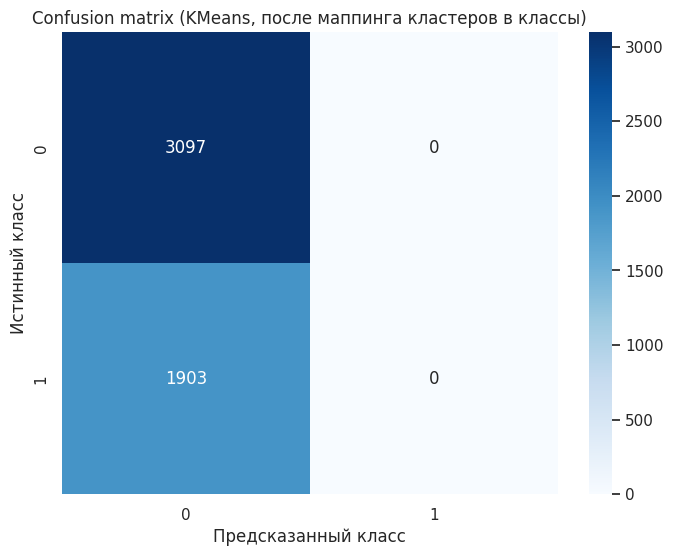

In [103]:
plt.figure()
sns.heatmap(cm_kmeans, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion matrix (KMeans, после маппинга кластеров в классы)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

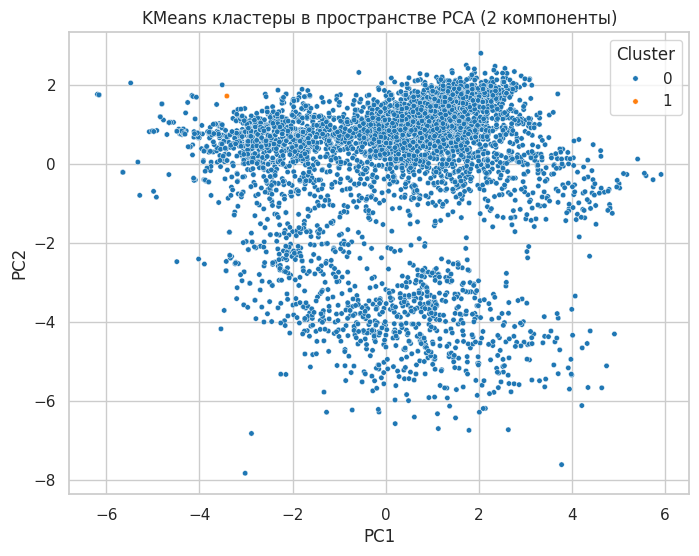

In [104]:
# Визуализация кластеров в пространстве PCA2
plt.figure()
sns.scatterplot(
    x=X_pca2_sub[:, 0],
    y=X_pca2_sub[:, 1],
    hue=kmeans_labels,
    s=15,
    palette="tab10"
)
plt.title("KMeans кластеры в пространстве PCA (2 компоненты)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

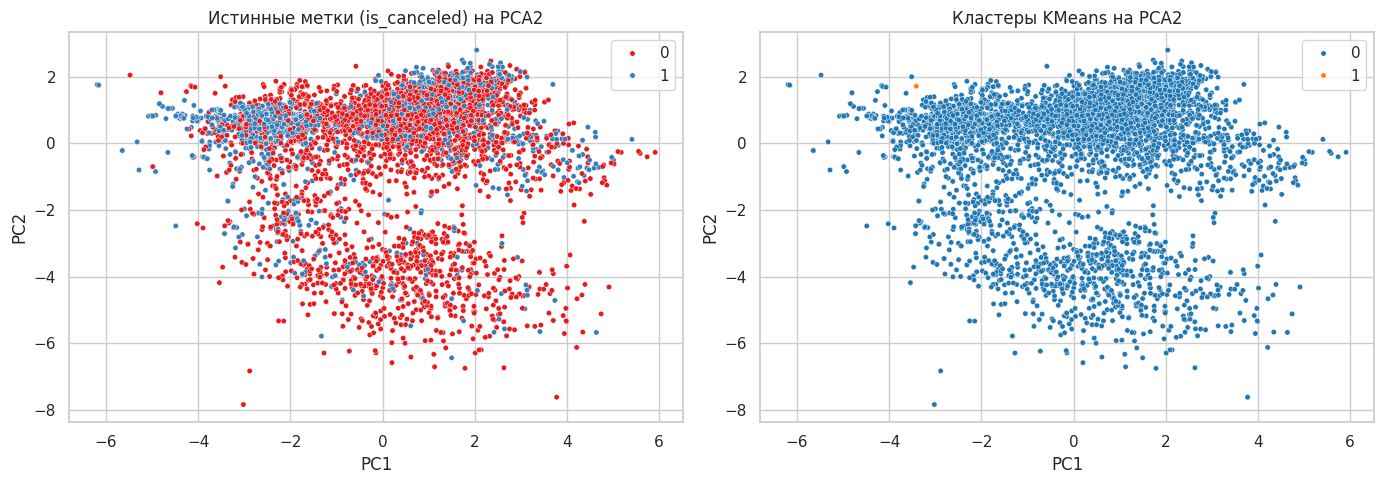

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    ax=axes[0],
    x=X_pca2_sub[:, 0],
    y=X_pca2_sub[:, 1],
    hue=y_sub,
    s=15,
    palette="Set1"
)
axes[0].set_title("Истинные метки (is_canceled) на PCA2")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

sns.scatterplot(
    ax=axes[1],
    x=X_pca2_sub[:, 0],
    y=X_pca2_sub[:, 1],
    hue=kmeans_labels,
    s=15,
    palette="tab10"
)
axes[1].set_title("Кластеры KMeans на PCA2")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

In [106]:
# 9. Agglomerative Clustering (иерархическая кластеризация)

print("\n9. Кластеризация методом AgglomerativeClustering...")

agg = AgglomerativeClustering(n_clusters=2)
agg_labels = agg.fit_predict(X_sub)

metrics_agg = evaluate_clustering(agg_labels, y_sub, "Agglomerative Clustering (2 кластера)")

pseudo_y_pred_agg, mapping_agg = map_clusters_to_classes(agg_labels, y_sub)
cm_agg = confusion_matrix(y_sub, pseudo_y_pred_agg)


9. Кластеризация методом AgglomerativeClustering...

=== Agglomerative Clustering (2 кластера) ===
Adjusted Rand Index (ARI): -0.0002
Normalized Mutual Information (NMI): 0.0003
Homogeneity: 0.0001
Completeness: 0.0503
V-measure: 0.0003

Таблица соответствия кластеров и истинных меток (crosstab):


is_canceled,0,1
cluster,,
0,3096,1903
1,1,0



Отображение кластеров Agglomerative -> классы:
{np.int64(0): np.int64(0), np.int64(1): np.int64(0)}


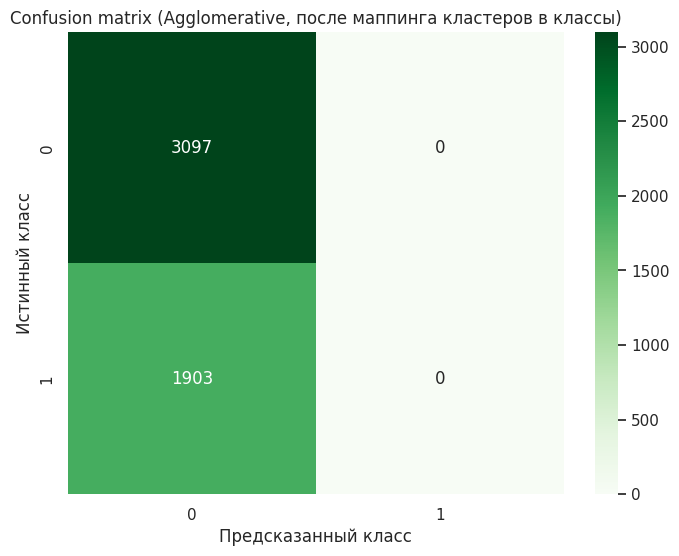

In [107]:
print("\nОтображение кластеров Agglomerative -> классы:")
print(mapping_agg)

plt.figure()
sns.heatmap(cm_agg, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion matrix (Agglomerative, после маппинга кластеров в классы)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

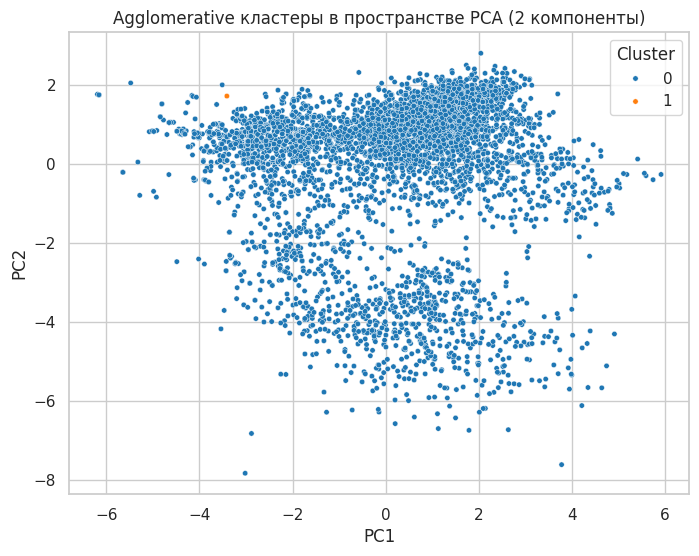

In [108]:
# Визуализация кластеров в PCA2
plt.figure()
sns.scatterplot(
    x=X_pca2_sub[:, 0],
    y=X_pca2_sub[:, 1],
    hue=agg_labels,
    s=15,
    palette="tab10"
)
plt.title("Agglomerative кластеры в пространстве PCA (2 компоненты)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

In [109]:
# 10. DBSCAN (на PCA10)

print("\n10. Кластеризация методом DBSCAN...")

dbscan = DBSCAN(eps=0.3, min_samples=10, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_pca10_sub)

unique_db, counts_db = np.unique(dbscan_labels, return_counts=True)
print("\nКластеры DBSCAN (label = -1 — шум):")
for lab, cnt in zip(unique_db, counts_db):
    print(f"   Метка {lab}: {cnt} объектов")


10. Кластеризация методом DBSCAN...

Кластеры DBSCAN (label = -1 — шум):
   Метка -1: 4928 объектов
   Метка 0: 11 объектов
   Метка 1: 10 объектов
   Метка 2: 13 объектов
   Метка 3: 13 объектов
   Метка 4: 12 объектов
   Метка 5: 13 объектов


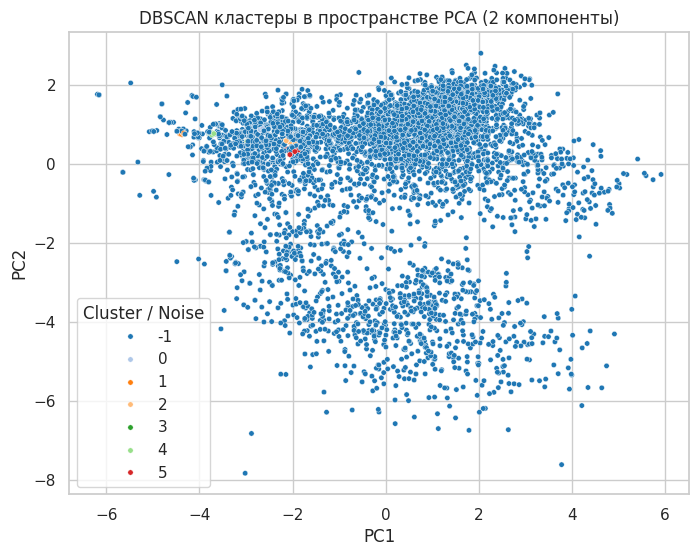

In [110]:
plt.figure()
sns.scatterplot(
    x=X_pca2_sub[:, 0],
    y=X_pca2_sub[:, 1],
    hue=dbscan_labels,
    s=15,
    palette="tab20"
)
plt.title("DBSCAN кластеры в пространстве PCA (2 компоненты)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster / Noise")
plt.show()

In [111]:
# 11. Сравнительная таблица метрик

print("\n11. Сравнение методов кластеризации по метрикам...")

results = pd.DataFrame({
    "Метод": ["KMeans (k=2)", "Agglomerative (2 кластера)", "DBSCAN (PCA10)"],
    "ARI": [metrics_kmeans["ARI"], metrics_agg["ARI"], metrics_dbscan["ARI"]],
    "NMI": [metrics_kmeans["NMI"], metrics_agg["NMI"], metrics_dbscan["NMI"]],
    "Homogeneity": [metrics_kmeans["H"], metrics_agg["H"], metrics_dbscan["H"]],
    "Completeness": [metrics_kmeans["C"], metrics_agg["C"], metrics_dbscan["C"]],
    "V-measure": [metrics_kmeans["V"], metrics_agg["V"], metrics_dbscan["V"]],
})

display(results)


11. Сравнение методов кластеризации по метрикам...


,Метод,ARI,NMI,Homogeneity,Completeness,V-measure
0,KMeans (k=2),-0.000154,0.000288,0.000144,0.050337,0.000288
1,Agglomerative (2 кластера),-0.000154,0.000288,0.000144,0.050337,0.000288
2,DBSCAN (PCA10),0.018479,0.036795,0.021197,0.139300,0.036795


In [112]:
# 12. ОБЩИЕ ВЫВОДЫ

print("\n12. ОБЩИЕ ВЫВОДЫ3:")

print("""
1. ДАННЫЕ:
   - Использован тот же датасет hotel_bookings (119390 объектов, 32 признака).
   - После удаления признаков с утечкой информации и целевой переменной,
     для кластеризации использовались 29 исходных признаков, расширенных
     до 248 признаков после One-Hot-Encoding.
   - Целевая переменная is_canceled сильно несбалансирована, но при этом
     её распределение не образует естественных кластеров в пространстве признаков.

2. ПРЕОБРАЗОВАНИЯ:
   - Выполнено заполнение пропусков медианой (для числовых признаков) и
     специальной категорией 'Unknown' (для категориальных признаков).
   - Признаки стандартизированы, что критично для KMeans, PCA и DBSCAN.
   - PCA до 2 компонент показал, что они объясняют лишь около 3% дисперсии,
     что говорит о высокой размерности и сложности структуры данных.
   - PCA до 10 компонент использовался для облегчения работы DBSCAN.

3. КЛАСТЕРИЗАЦИЯ:
   - Методы кластеризации (KMeans, AgglomerativeClustering, DBSCAN) обучались
     без использования целевой переменной is_canceled. Целевая метка
     использовалась только для оценки качества кластеризации.

4. РЕЗУЛЬТАТЫ:
   - Все метрики, сравнивающие кластеры с истинными метками (ARI, NMI,
     Homogeneity, Completeness, V-measure), для всех трёх методов оказались
     близки к нулю.
   - Это означает, что структуры кластеров, найденные алгоритмами, практически
     не совпадают с разделением объектов по признаку отмены брони.
   - KMeans и AgglomerativeClustering формируют два кластера, но они
     не соответствуют классам 'отменено / не отменено'.
   - DBSCAN на PCA-признаках выделяет один большой кластер и небольшой шум,
     что говорит об отсутствии чётких плотностных структур.

5. ВЫВОДЫ:
   - Задача предсказания отмены бронирования (is_canceled) НЕ является задачей
     выявления естественных кластеров в данных.
   - Методы обучения без учителя (кластеризация) не справляются с восстановлением
     структуры целевой переменной.
   - Для решения такой задачи лучше подходят методы обучения с учителем
     (логистическая регрессия, Random Forest, градиентный бустинг и т.п.).
""")


12. ОБЩИЕ ВЫВОДЫ3:

1. ДАННЫЕ:
   - Использован тот же датасет hotel_bookings (119390 объектов, 32 признака).
   - После удаления признаков с утечкой информации и целевой переменной,
     для кластеризации использовались 29 исходных признаков, расширенных
     до 248 признаков после One-Hot-Encoding.
   - Целевая переменная is_canceled сильно несбалансирована, но при этом
     её распределение не образует естественных кластеров в пространстве признаков.

2. ПРЕОБРАЗОВАНИЯ:
   - Выполнено заполнение пропусков медианой (для числовых признаков) и
     специальной категорией 'Unknown' (для категориальных признаков).
   - Признаки стандартизированы, что критично для KMeans, PCA и DBSCAN.
   - PCA до 2 компонент показал, что они объясняют лишь около 3% дисперсии,
     что говорит о высокой размерности и сложности структуры данных.
   - PCA до 10 компонент использовался для облегчения работы DBSCAN.

3. КЛАСТЕРИЗАЦИЯ:
   - Методы кластеризации (KMeans, AgglomerativeClustering, DBSCAN) обучал